In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct relative path (tabular_4)
file_path = "./tabular4_train.csv"   # 若还没切分，可用 "./tabular4.csv"
label_col = "label"

# Load dataset
df_train = pd.read_csv(file_path)

# 兼容：如果还是原始列名，就顺手改成 label
if "Diabetes_012" in df_train.columns and "label" not in df_train.columns:
    df_train = df_train.rename(columns={"Diabetes_012": "label"})

print("Data shape:", df_train.shape)
print("Columns:", list(df_train.columns))





Data shape: (152207, 10)
Columns: ['label', 'Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack', 'site_id']


In [4]:
%pip install -U pip
%pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.7-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (112 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.7 MB/s  0:00:00
Using cached matplotlib-3.10.7-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.2.5-py3-none

In [2]:
# 计算与标签的皮尔逊相关（tabular_4）
# 若你上一步把 label_col 设为 "label"，这里直接用即可
corr = df_train.corr(numeric_only=True)

# 取出与标签列的相关系数，去掉标签本身，并按绝对值降序
corr_series = corr[label_col].drop(labels=[label_col], errors='ignore')
corr_abs_sorted = corr_series.abs().sort_values(ascending=False)

print("\nTop 15 correlated features with label:")
print(corr_series.reindex(corr_abs_sorted.index[:15]))



Top 15 correlated features with label:
GenHlth                 0.305116
HighBP                  0.274154
DiffWalk                0.228567
BMI                     0.225727
HighChol                0.209116
Age                     0.187485
HeartDiseaseorAttack    0.183409
Sex                     0.030258
site_id                 0.000003
Name: label, dtype: float64


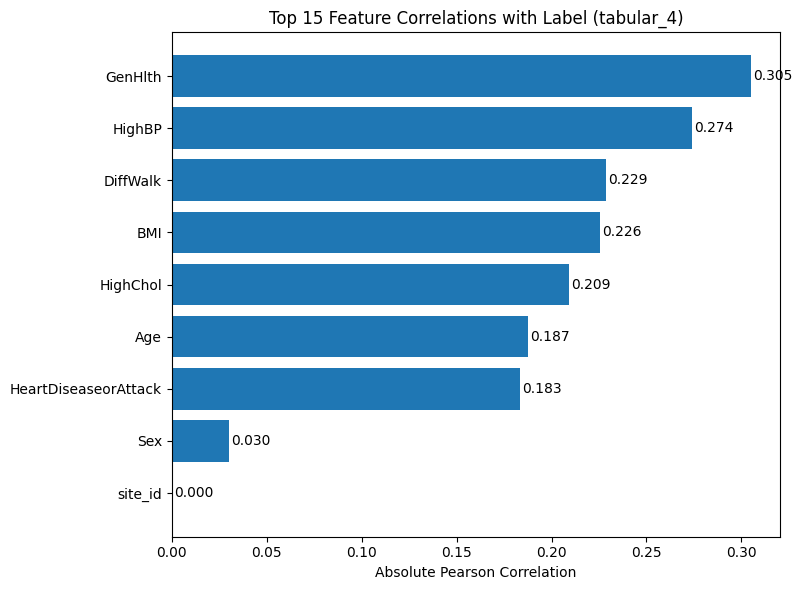

In [3]:
# Visualize top 15 absolute correlations (matplotlib only)
vals = corr_abs_sorted.values[:15]
names = corr_abs_sorted.index[:15]

plt.figure(figsize=(8,6))
ypos = np.arange(len(names))
plt.barh(ypos, vals)
plt.yticks(ypos, names)
plt.gca().invert_yaxis()  # 让相关性最大的在最上
plt.title("Top 15 Feature Correlations with Label (tabular_4)")
plt.xlabel("Absolute Pearson Correlation")
plt.tight_layout()

# 可选：标数值
for i, v in enumerate(vals):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")

plt.show()


In [4]:
# Select the final 8 template features and save  (tabular_4)
# Prerequisite: corr_abs_sorted and df_train, label_col are already defined

from collections import OrderedDict
import json
import pandas as pd
from pathlib import Path

# 1) 固定“通用核心特征”
core_features = ["Age", "Sex", "BMI"]

# 2) 从相关性榜单取候选（排除 label 本身）
candidates = [c for c in corr_abs_sorted.index if c != label_col]

# 3) 合并并保持顺序；只保留当前数据里真实存在的列
merged = list(OrderedDict.fromkeys(core_features + candidates))
merged = [c for c in merged if c in df_train.columns and c != label_col]

# 4) 截取 8 个；如果前面不足 8（极少见），就把 df_train 里的其他可用列也补上
mask_features = merged[:8]
if len(mask_features) < 8:
    others = [c for c in df_train.columns if c not in mask_features + [label_col]]
    mask_features = (mask_features + others)[:8]

print("Final 8 template features:", mask_features)

# 5) 保存为 CSV（单列 feature）与 JSON（版本/标签名/特征列表）
out_dir = Path("feature_templates")
out_dir.mkdir(exist_ok=True)

# CSV（与你 tabular_3 的风格一致）
pd.Series(mask_features, name="feature").to_csv(out_dir / "feature_template_v1.csv", index=False)

# JSON（便于后续对齐用）
template_meta = {
    "version": "v1",
    "label": "label",           # tabular_4 统一使用 'label'
    "features": mask_features
}
(out_dir / "feature_template_v1.json").write_text(json.dumps(template_meta, indent=2), encoding="utf-8")

print("Saved:", out_dir / "feature_template_v1.csv")
print("Saved:", out_dir / "feature_template_v1.json")


Final 8 template features: ['Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack']
Saved: feature_templates/feature_template_v1.csv
Saved: feature_templates/feature_template_v1.json
